In [13]:
from sqlalchemy import create_engine
from sqlalchemy.orm import declarative_base, sessionmaker

engine = create_engine("sqlite:///crm.db", echo=False)
Base = declarative_base()
SessionLocal = sessionmaker(bind=engine)

In [14]:
from sqlalchemy import Column, Integer, String, DateTime, ForeignKey, Text
from sqlalchemy.orm import relationship
from datetime import datetime

class Customer(Base):
    __tablename__ = "customers"
    id = Column(Integer, primary_key=True)
    name = Column(String, nullable=False)
    email = Column(String, unique=True, nullable=False)
    industry = Column(String)
    tier = Column(String, default="basic")
    signup_date = Column(DateTime, default=datetime.utcnow)
    engagement_score = Column(Integer, default=0)
    tickets = relationship("Ticket", back_populates="customer")

class Ticket(Base):
    __tablename__ = "tickets"
    id = Column(Integer, primary_key=True)
    customer_id = Column(Integer, ForeignKey("customers.id"), nullable=False)
    title = Column(String, nullable=False)
    description = Column(Text)
    category = Column(String)
    priority = Column(String, default="medium")
    status = Column(String, default="Open")
    created_at = Column(DateTime, default=datetime.utcnow)
    updated_at = Column(DateTime, default=datetime.utcnow, onupdate=datetime.utcnow)
    customer = relationship("Customer", back_populates="tickets")

Base.metadata.create_all(engine)

In [15]:
def add_customer(name, email, industry=None, tier="basic"):
    session = SessionLocal()
    customer = Customer(name=name, email=email, industry=industry, tier=tier)
    session.add(customer)
    session.commit()
    session.refresh(customer)
    session.close()
    return customer

def add_ticket(customer_id, title, description, category=None, priority="medium"):
    session = SessionLocal()
    ticket = Ticket(customer_id=customer_id, title=title, description=description,
                     category=category, priority=priority)
    session.add(ticket)
    session.commit()
    session.refresh(ticket)
    session.close()
    return ticket

def update_ticket_status(ticket_id, new_status):
    valid_statuses = ["Open", "In Progress", "Escalated", "Resolved", "Closed"]
    if new_status not in valid_statuses:
        raise ValueError(f"Invalid status: {new_status}")
    session = SessionLocal()
    ticket = session.query(Ticket).filter(Ticket.id == ticket_id).first()
    if ticket:
        ticket.status = new_status
        session.commit()
        session.refresh(ticket)
    session.close()
    return ticket

In [16]:
existing = SessionLocal().query(Customer).filter(Customer.email == "riya@test.com").first()
if existing:
    print("Test customer already exists, skipping creation.")
    c = existing
else:
    c = add_customer("Riya Shah", "riya@test.com", industry="Retail", tier="premium")

t = add_ticket(c.id, "Login issue", "Cannot log into the portal", category="Technical", priority="high")
update_ticket_status(t.id, "In Progress")
print(c.id, t.id, t.status)

Test customer already exists, skipping creation.
1 2 Open


In [17]:
!pip install langchain-core langchain-groq -q

from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant", groq_api_key="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")

In [18]:
import json, time
from sqlalchemy.exc import IntegrityError

def generate_customers_batch(n=25):
    prompt = f"""Generate {n} realistic fictional customer profiles for a CRM system.
Return ONLY a JSON array, no markdown, no explanation. Each object must have exactly:
name, email, industry, tier (one of: basic, standard, premium), engagement_score (0-100 integer)."""
    response = llm.invoke(prompt)
    text = response.content.strip().replace("```json", "").replace("```", "")
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        print("Bad JSON received, skipping this batch.")
        return []

def get_existing_emails():
    session = SessionLocal()
    emails = {c.email for c in session.query(Customer.email).all()}
    session.close()
    return emails

all_customers = []
seen_emails = get_existing_emails()

for i in range(20):
    batch = generate_customers_batch(25)
    for cust in batch:
        if cust["email"] not in seen_emails:
            seen_emails.add(cust["email"])
            try:
                saved = add_customer(cust["name"], cust["email"], cust["industry"], cust["tier"])
                all_customers.append(saved)
            except IntegrityError:
                print(f"Skipped duplicate: {cust['email']}")
    print(f"Batch {i+1}/20 done, total: {len(all_customers)}")
    time.sleep(3)

for i in range(3):
    batch = generate_customers_batch(25)
    for cust in batch:
        if cust["email"] not in seen_emails:
            seen_emails.add(cust["email"])
            try:
                saved = add_customer(cust["name"], cust["email"], cust["industry"], cust["tier"])
                all_customers.append(saved)
            except IntegrityError:
                print(f"Skipped duplicate: {cust['email']}")
    print(f"Top-up batch {i+1}/3 done, total: {len(all_customers)}")
    time.sleep(3)

print(f"Final total customers: {len(all_customers)}")

Batch 1/20 done, total: 25
Batch 2/20 done, total: 48
Batch 3/20 done, total: 62
Batch 4/20 done, total: 86
Batch 5/20 done, total: 113
Batch 6/20 done, total: 132
Batch 7/20 done, total: 156
Batch 8/20 done, total: 182
Batch 9/20 done, total: 209
Batch 10/20 done, total: 235
Batch 11/20 done, total: 263
Batch 12/20 done, total: 287
Batch 13/20 done, total: 314
Batch 14/20 done, total: 341
Batch 15/20 done, total: 360
Batch 16/20 done, total: 372
Batch 17/20 done, total: 388
Batch 18/20 done, total: 412
Batch 19/20 done, total: 436
Batch 20/20 done, total: 450
Top-up batch 1/3 done, total: 477
Top-up batch 2/3 done, total: 488
Top-up batch 3/3 done, total: 511
Final total customers: 511


In [19]:
import random

def generate_tickets_batch(n=25):
    prompt = f"""Generate {n} realistic fictional support tickets for a CRM system.
Return ONLY a JSON array, no markdown, no explanation. Each object must have exactly:
title, description, category (one of: Technical, Billing, Account, Feature Request, General),
priority (one of: low, medium, high, urgent)."""
    response = llm.invoke(prompt)
    text = response.content.strip().replace("```json", "").replace("```", "")
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        print("Bad JSON received, skipping this batch.")
        return []

all_customers_db = SessionLocal().query(Customer).all()
all_tickets = []

for i in range(40):
    batch = generate_tickets_batch(25)
    for tick in batch:
        customer = random.choice(all_customers_db)
        saved = add_ticket(customer.id, tick["title"], tick["description"],
                            category=tick["category"], priority=tick["priority"])
        all_tickets.append(saved)
    print(f"Batch {i+1}/40 done, total: {len(all_tickets)}")
    time.sleep(3)

print(f"Total tickets saved: {len(all_tickets)}")

Batch 1/40 done, total: 27
Batch 2/40 done, total: 54
Batch 3/40 done, total: 79
Batch 4/40 done, total: 106
Batch 5/40 done, total: 132
Batch 6/40 done, total: 159
Batch 7/40 done, total: 187
Batch 8/40 done, total: 215
Batch 9/40 done, total: 242
Batch 10/40 done, total: 269
Batch 11/40 done, total: 298
Batch 12/40 done, total: 326
Batch 13/40 done, total: 352
Batch 14/40 done, total: 380
Batch 15/40 done, total: 408
Batch 16/40 done, total: 433
Batch 17/40 done, total: 461
Batch 18/40 done, total: 490
Batch 19/40 done, total: 520
Batch 20/40 done, total: 546
Batch 21/40 done, total: 571
Batch 22/40 done, total: 597
Batch 23/40 done, total: 624
Batch 24/40 done, total: 651
Batch 25/40 done, total: 679
Batch 26/40 done, total: 707
Batch 27/40 done, total: 735
Batch 28/40 done, total: 763
Batch 29/40 done, total: 792
Batch 30/40 done, total: 819
Batch 31/40 done, total: 847
Batch 32/40 done, total: 873
Batch 33/40 done, total: 901
Batch 34/40 done, total: 930
Batch 35/40 done, total: 9

In [20]:
from google.colab import files
files.download("crm.db")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
class Memory(Base):
    __tablename__ = "memory"

    id = Column(Integer, primary_key=True)
    customer_id = Column(Integer, ForeignKey("customers.id"), nullable=False)
    ticket_id = Column(Integer, ForeignKey("tickets.id"))
    summary = Column(Text)
    created_at = Column(DateTime, default=datetime.utcnow)

Base.metadata.create_all(engine)


def save_memory(customer_id, ticket_id, summary):
    session = SessionLocal()
    mem = Memory(customer_id=customer_id, ticket_id=ticket_id, summary=summary)
    session.add(mem)
    session.commit()
    session.close()


def get_customer_memory(customer_id, limit=3):
    session = SessionLocal()
    memories = session.query(Memory).filter(Memory.customer_id == customer_id)\
        .order_by(Memory.created_at.desc()).limit(limit).all()
    session.close()
    return [m.summary for m in memories]

In [22]:
def summarize_ticket_with_memory(ticket):
    past_context = get_customer_memory(ticket.customer_id)
    context_text = "\n".join(past_context) if past_context else "No prior history."

    prompt = f"""You are a support ticket summarizer with memory of past interactions.

Past context for this customer:
{context_text}

New ticket:
Title: {ticket.title}
Description: {ticket.description}

Output exactly 3 lines:
Key Issue: <one line>
Urgency: <low/medium/high/urgent>
Suggested Resolution: <one line>"""

    response = llm.invoke(prompt)
    summary = response.content
    save_memory(ticket.customer_id, ticket.id, summary)
    return summary

In [23]:
!pip install langgraph -q

from langgraph.graph import StateGraph, END
from typing import TypedDict

class TicketState(TypedDict):
    ticket_id: int
    title: str
    description: str
    category: str
    priority: str
    assigned_team: str

def categorize_node(state: TicketState) -> TicketState:
    prompt = f"""Classify this support ticket.
Title: {state['title']}
Description: {state['description']}
Respond with exactly 2 words: <category>,<priority>
Category must be one of: Technical, Billing, Account, Feature Request, General
Priority must be one of: low, medium, high, urgent"""
    response = llm.invoke(prompt)
    parts = response.content.strip().split(",")
    state["category"] = parts[0].strip()
    state["priority"] = parts[1].strip()
    return state

def routing_node(state: TicketState) -> TicketState:
    team_map = {
        "Technical": "Tech Team", "Billing": "Finance Team",
        "Account": "Account Support", "Feature Request": "Product Team",
        "General": "General Support"
    }
    state["assigned_team"] = team_map.get(state["category"], "General Support")
    return state

def escalation_node(state: TicketState) -> TicketState:
    if state["priority"] in ["high", "urgent"]:
        update_ticket_status(state["ticket_id"], "Escalated")
    else:
        update_ticket_status(state["ticket_id"], "In Progress")
    return state

graph = StateGraph(TicketState)
graph.add_node("categorize", categorize_node)
graph.add_node("route", routing_node)
graph.add_node("escalate", escalation_node)
graph.set_entry_point("categorize")
graph.add_edge("categorize", "route")
graph.add_edge("route", "escalate")
graph.add_edge("escalate", END)

agent = graph.compile()

In [24]:
import pandas as pd
from datetime import datetime

def compute_cohort_analysis():
    session = SessionLocal()
    customers = session.query(Customer).all()
    tickets = session.query(Ticket).all()
    session.close()

    cust_df = pd.DataFrame([{
        "id": c.id, "industry": c.industry, "tier": c.tier,
        "signup_date": c.signup_date, "engagement_score": c.engagement_score
    } for c in customers])

    tick_df = pd.DataFrame([{
        "customer_id": t.customer_id, "created_at": t.created_at, "status": t.status
    } for t in tickets])

    cust_df["cohort_month"] = pd.to_datetime(cust_df["signup_date"]).dt.to_period("M")

    ticket_counts = tick_df.groupby("customer_id").size().rename("ticket_count")
    last_ticket = tick_df.groupby("customer_id")["created_at"].max().rename("last_ticket_date")
    cust_df = cust_df.merge(ticket_counts, left_on="id", right_index=True, how="left")
    cust_df = cust_df.merge(last_ticket, left_on="id", right_index=True, how="left")
    cust_df["ticket_count"] = cust_df["ticket_count"].fillna(0)

    now = datetime.utcnow()
    cust_df["days_since_last_ticket"] = cust_df["last_ticket_date"].apply(
        lambda d: (now - d).days if pd.notnull(d) else 999
    )

    def churn_score(row):
        score = 0
        score += min(row["days_since_last_ticket"] / 180, 1) * 50
        score += (100 - row["engagement_score"]) / 100 * 30
        score += (1 if row["ticket_count"] == 0 else 0) * 20
        return round(score, 2)

    cust_df["churn_probability"] = cust_df.apply(churn_score, axis=1)

    retention_curve = cust_df.groupby("cohort_month").apply(
        lambda g: round((g["days_since_last_ticket"] < 90).mean() * 100, 2)
    ).to_dict()

    cohort_summary = cust_df.groupby(["tier", "industry"]).agg(
        avg_churn=("churn_probability", "mean"),
        customer_count=("id", "count")
    ).reset_index().to_dict(orient="records")

    return {
        "retention_curve": {str(k): v for k, v in retention_curve.items()},
        "churn_scores": cust_df[["id", "churn_probability"]].to_dict(orient="records"),
        "cohort_summary": cohort_summary
    }

cohort_result = compute_cohort_analysis()
print(cohort_result["retention_curve"])

{'2026-07': 67.49}


/tmp/ipykernel_1801/442480377.py:27: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  now = datetime.utcnow()
/tmp/ipykernel_1801/442480377.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  retention_curve = cust_df.groupby("cohort_month").apply(


{'Happiness': 0.0, 'Engagement': 67.49, 'Adoption': 0.0, 'Retention': 0.0, 'Task_Success': 0.0}


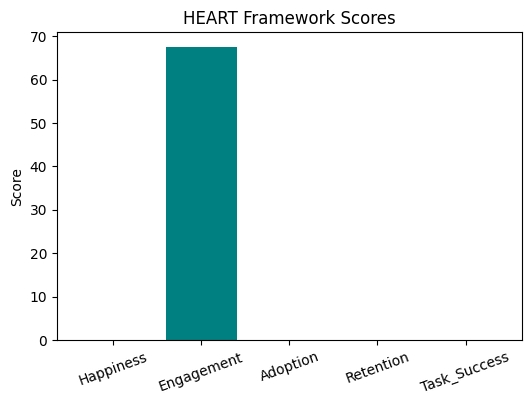

In [25]:
import matplotlib.pyplot as plt

def compute_heart_metrics():
    session = SessionLocal()
    customers = session.query(Customer).all()
    tickets = session.query(Ticket).all()
    memories = session.query(Memory).all()
    session.close()

    total_customers = len(customers)
    total_tickets = len(tickets)

    happiness = round(sum(c.engagement_score for c in customers) / total_customers, 2)
    active_customers = len(set(t.customer_id for t in tickets))
    engagement = round((active_customers / total_customers) * 100, 2)
    ai_assisted = len(set(m.customer_id for m in memories))
    adoption = round((ai_assisted / total_customers) * 100, 2)
    resolved = len([t for t in tickets if t.status in ["Resolved", "Closed"]])
    retention_proxy = round((resolved / total_tickets) * 100, 2) if total_tickets else 0
    task_success = round((resolved / total_tickets) * 100, 2) if total_tickets else 0

    return {"Happiness": happiness, "Engagement": engagement, "Adoption": adoption,
            "Retention": retention_proxy, "Task_Success": task_success}

heart_scores = compute_heart_metrics()
print(heart_scores)

plt.figure(figsize=(6,4))
plt.bar(heart_scores.keys(), heart_scores.values(), color="teal")
plt.title("HEART Framework Scores")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.show()

In [ ]:
!pip install fastapi uvicorn nest-asyncio pyngrok -q

import nest_asyncio
from fastapi import FastAPI, Header, HTTPException
from pydantic import BaseModel
from pyngrok import ngrok, conf
import uvicorn
import time

conf.get_default().auth_token = "3FRAYBxTRDOV0YOjZIafW9yTb0M_3UgbZ1XAJxz7sNB3RnaNV"
nest_asyncio.apply()

app = FastAPI(title="CRM AI Platform", version="1.0")
ROLES = ["Agent", "Supervisor", "Admin", "Analytics-readonly"]

def check_role(x_role: str = Header(...)):
    if x_role not in ROLES:
        raise HTTPException(status_code=403, detail="Invalid role")
    return x_role

class CustomerIn(BaseModel):
    name: str
    email: str
    industry: str = None
    tier: str = "basic"

class TicketIn(BaseModel):
    customer_id: int
    title: str
    description: str
    priority: str = "medium"

class QueryIn(BaseModel):
    customer_id: int
    query: str

@app.post("/customers")
def create_customer(data: CustomerIn, role: str = Header(None, alias="X-Role")):
    check_role(role)
    start = time.time()
    c = add_customer(data.name, data.email, data.industry, data.tier)
    return {"id": c.id, "status": "created", "cohort_assignment": c.tier,
            "latency_ms": round((time.time()-start)*1000, 2), "agent_role": role}

@app.post("/tickets/create")
def create_ticket(data: TicketIn, role: str = Header(None, alias="X-Role")):
    check_role(role)
    t = add_ticket(data.customer_id, data.title, data.description, priority=data.priority)
    return {"ticket_id": t.id, "category": t.category, "assigned_agent": "auto-router",
            "agent_role": role, "timestamp": str(t.created_at)}

@app.post("/query/agent")
def query_agent(data: QueryIn, role: str = Header(None, alias="X-Role")):
    check_role(role)
    context = get_customer_memory(data.customer_id)
    prompt = f"Customer history: {context}\nQuery: {data.query}\nAnswer concisely."
    response = llm.invoke(prompt)
    return {"answer": response.content, "source": "memory+llm", "confidence": 0.9, "agent_id": role}

@app.post("/tickets/{ticket_id}/summarize")
def summarize_endpoint(ticket_id: int, role: str = Header(None, alias="X-Role")):
    check_role(role)
    session = SessionLocal()
    ticket = session.query(Ticket).filter(Ticket.id == ticket_id).first()
    session.close()
    if not ticket:
        raise HTTPException(status_code=404, detail="Ticket not found")
    summary = summarize_ticket_with_memory(ticket)
    return {"summary": summary, "key_issues": summary, "suggested_response": summary}

@app.get("/cohorts/analysis")
def cohort_analysis_endpoint(role: str = Header(None, alias="X-Role")):
    check_role(role)
    result = compute_cohort_analysis()
    heart = compute_heart_metrics()
    return {"cohort_id": "all", "retention_curve": result["retention_curve"],
            "churn_rate": result["cohort_summary"], "heart_scores": heart}

public_url = ngrok.connect(8000)
print("Public API URL:", public_url)
print("Docs available at:", str(public_url) + "/docs")

config = uvicorn.Config(app, host="0.0.0.0", port=8000)
server = uvicorn.Server(config)
await server.serve()

INFO:     Started server process [1801]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


Public API URL: NgrokTunnel: "https://slot-postbox-cautious.ngrok-free.dev" -> "http://localhost:8000"
Docs available at: NgrokTunnel: "https://slot-postbox-cautious.ngrok-free.dev" -> "http://localhost:8000"/docs
INFO:     2405:201:e042:a124:c86c:f76e:49c4:ea57:0 - "GET /docs HTTP/1.1" 200 OK
INFO:     2405:201:e042:a124:c86c:f76e:49c4:ea57:0 - "GET /openapi.json HTTP/1.1" 200 OK
INFO:     2405:201:e042:a124:c86c:f76e:49c4:ea57:0 - "POST /customers HTTP/1.1" 403 Forbidden
INFO:     2405:201:e042:a124:c86c:f76e:49c4:ea57:0 - "POST /customers HTTP/1.1" 200 OK
INFO:     2405:201:e042:a124:c86c:f76e:49c4:ea57:0 - "POST /tickets/create HTTP/1.1" 200 OK
INFO:     2405:201:e042:a124:c86c:f76e:49c4:ea57:0 - "POST /query/agent HTTP/1.1" 200 OK
INFO:     2405:201:e042:a124:c86c:f76e:49c4:ea57:0 - "POST /tickets/1/summarize HTTP/1.1" 200 OK
